In [2]:
import xgi
import numpy as np
from tqdm import tqdm
import pickle
from multiprocess import Pool
from had_model import HAD_model
import matplotlib.pyplot as plt

# Results as a function of $\epsilon$

- number of connected components
- size of the largest connected component
- size of the second largest connected component
- number of hyperedges
- average hyperedge size
- max hyperedge size

    
Results averaged over 20 iterations, $\langle k \rangle = 10$ 
for the starting uniform Erdos-Renyi hypergraphs.

In [3]:
epsilons = np.linspace(0.4, 0.6, num=9)[1:]  # np.linspace(0., 0.4, num=17)[1:]
cond = 'max_min'   # condition for agreement
Ms = [2, 4, 6]
Ns = [500, 1000, 2000, 5000]
k_avg = 10
iterations = 20    # number of iterations for each epsilon

# auxiliary functions to parallelize computations
def get_results(M):
    
    ncc = dict()
    scc1 = dict()
    scc2 = dict()
    nhe = dict()
    s_avg = dict()
    s_max = dict()
    
    for N in Ns:
        
        # All below quantities are computed at the steady state, as a function of epsilon, averaged over 'iterations'
        ncc[N] = []      # number of connected components
        scc1[N] = []     # size of the largest connected component
        scc2[N] = []     # size of the second largest connected component
        nhe[N] = []      # number of hyperedges
        s_avg[N] = []    # average hyperedge size
        s_max[N] = []    # max hyperedge size
                      
        for eps in tqdm(epsilons):
        
            ncc_it = []
            scc1_it, scc2_it = [], []
            nhe_it = []
            s_avg_it, s_max_it = [], []
            
            for it in range(iterations):
                
                H = xgi.uniform_erdos_renyi_hypergraph(N, M, k_avg, p_type="degree")
                H.cleanup()
                groups_0 = H.edges.members()
                
                Model = HAD_model(eps, groups_0)
                results = Model.simulate(condition=cond)
                opinions = results['opinions']
                groups = results['groups']
                
                # number of connected components and size of the two largest
                hedges = groups[-1]
                h = xgi.Hypergraph(hedges)
                # list of connected components
                cc = [j for j in xgi.connected_components(h)]
                ncc_it.append( len(cc) )                    
                scc = set([len(i) for i in cc])
                scc1_it.append( max(scc) / N )
                scc.remove(max(scc))
                if scc:
                    scc2_it.append( max(scc) / N )
                else:
                    scc2_it.append(0)
        
                # relative number of hyperedges
                nhe_it.append( len(groups[-1]) / len(groups_0) )
                
                # relative avg and std of hyperedge sizes
                sizes_end_it = [len(e) for e in groups[-1]]
                s_avg_it.append( np.mean(sizes_end_it) )
                s_max_it.append( np.max(sizes_end_it) )
                
            ncc[N].append(np.mean(ncc_it))
            scc1[N].append(np.mean(scc1_it))
            scc2[N].append(np.mean(scc2_it))
            nhe[N].append(np.mean(nhe_it))
            s_avg[N].append(np.mean(s_avg_it))
            s_max[N].append(np.mean(s_max_it))

    results = {
        'epsilons': epsilons,
        'ncc': ncc,
        'scc1': scc1,
        'scc2': scc2,
        'nhe': nhe,
        's_avg': s_avg,
        's_max': s_max
        }
    
    return results

In [5]:
p = Pool(processes=6)
results = p.map(get_results, Ms)

# save results
for i in range(len(Ms)):
    with open(f'../results/ER_M{Ms[i]}_{cond}.pkl', 'wb') as fp:
            pickle.dump(results[i], fp)

100%|█████████████████████████████████████████| 8/8 [2:40:16<00:00, 1202.05s/it]


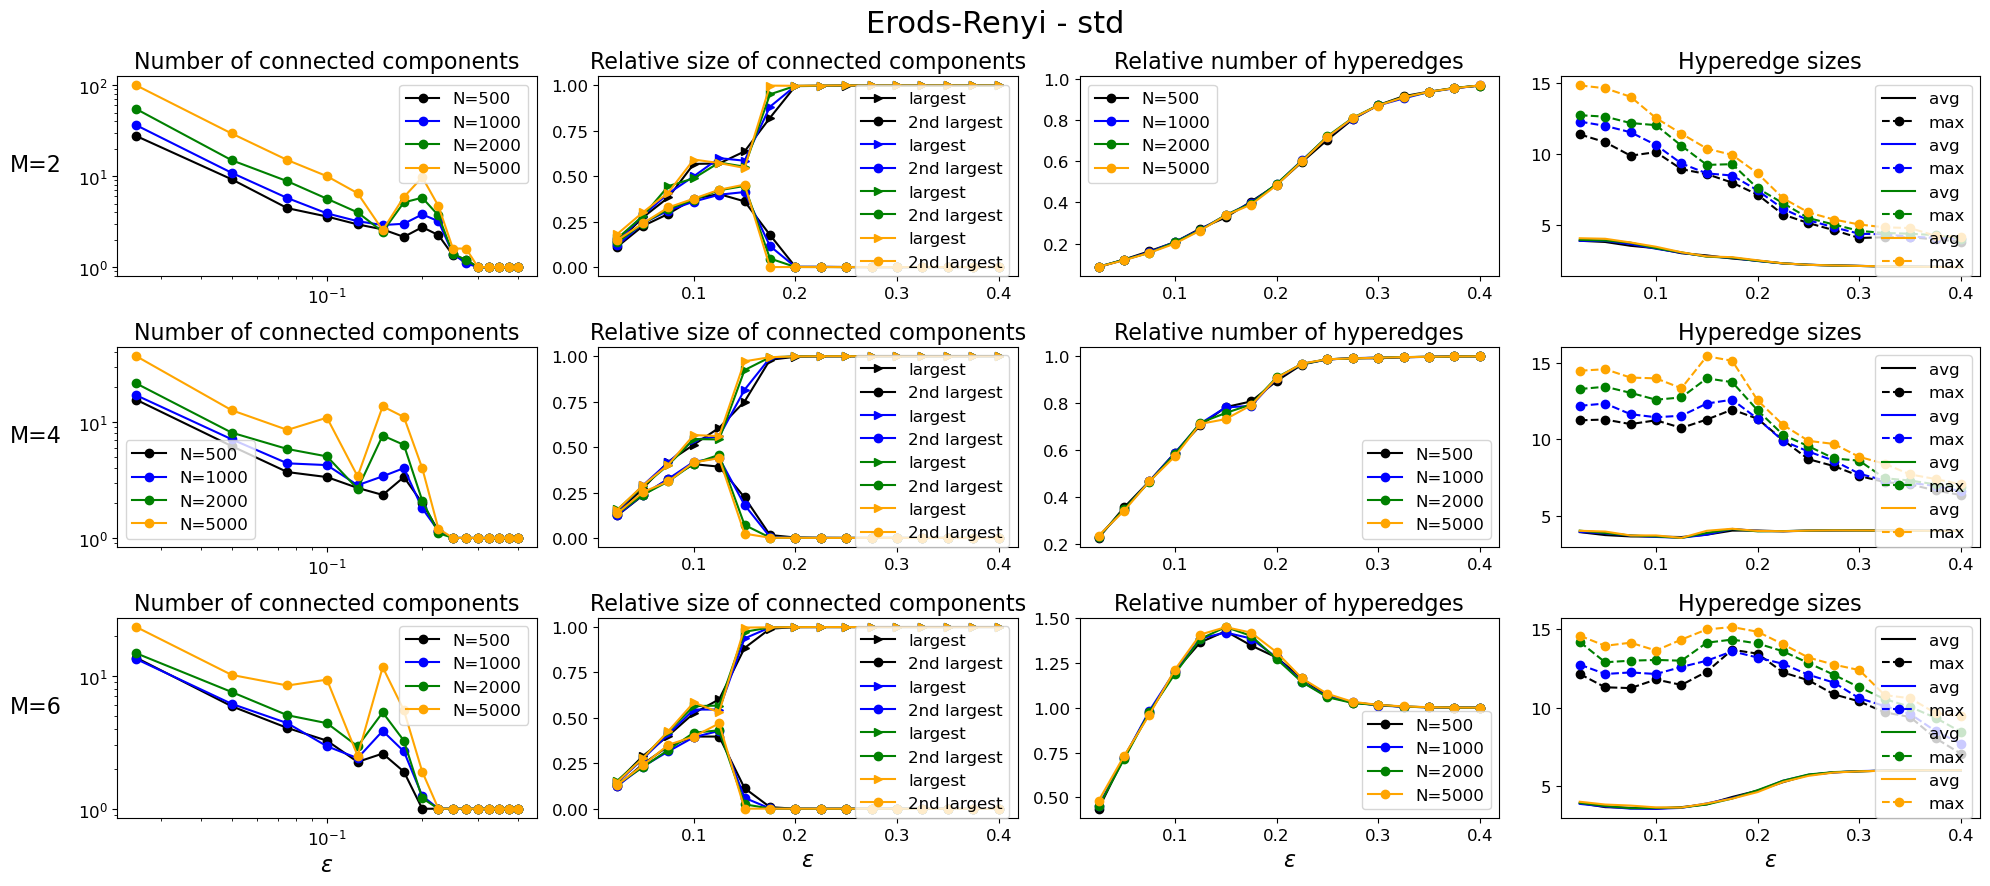

In [6]:
cond = 'std' 
Ns = [500, 1000, 2000, 5000]
Ms = [2, 4, 6]

ncol = 4
fig, axs = plt.subplots(len(Ms), ncol, figsize=(20, 3*len(Ms)))
ttl_size = 16
lgd_size = 12
colors = ['black', 'blue', 'green', 'orange']  # one color for each value of N

for M in Ms:

    with open(f'../results/ER_M{M}_{cond}.pkl', 'rb') as f:
        results = pickle.load(f)
        
    epsilons = results['epsilons']
    ncc = results['ncc']
    scc1 = results['scc1']
    scc2 = results['scc2']
    nhe = results['nhe']
    s_avg = results['s_avg']
    s_max = results['s_max']

    lbls = ['largest', '2nd largest', 'avg', 'max']
    for N,clr in zip(Ns, colors):
                                   
        i = Ms.index(M)
        y0 = ncc[N]
        y1 = scc1[N]
        y2 = scc2[N]
        y3 = nhe[N]
        y4 = s_avg[N]
        y5 = s_max[N]
        
        axs[i,0].plot(epsilons, y0, color=clr, marker='o', label=f'N={N}')
        axs[i,0].set_xscale('log')
        axs[i,0].set_yscale('log')
        axs[i,0].legend(fontsize=lgd_size)
        axs[i,0].set_title('Number of connected components', fontsize=ttl_size)
 
        axs[i,1].plot(epsilons, y1, color=clr, linestyle='-', marker='>', label=lbls[0])
        axs[i,1].plot(epsilons, y2, color=clr, linestyle='-', marker='o', label=lbls[1])
        axs[i,1].legend(fontsize=lgd_size)
        axs[i,1].set_title('Relative size of connected components', fontsize=ttl_size)
        
        axs[i,2].plot(epsilons, y3, color=clr, marker='o', label=f'N={N}')
        axs[i,2].legend(fontsize=lgd_size)
        axs[i,2].set_title('Relative number of hyperedges', fontsize=ttl_size)
        
        axs[i,3].plot(epsilons, y4, label=lbls[2], color=clr)
        axs[i,3].plot(epsilons, y5, label=lbls[3], linestyle='--', marker='o', color=clr)
        axs[i,3].legend(fontsize=lgd_size)
        axs[i,3].set_title('Hyperedge sizes', fontsize=ttl_size)

        # set tick fontsize in all subplots
        for j in range(4):
            axs[i,j].tick_params(labelsize=12)
        #lbls = [None for jj in lbls]

    axs[i,0].set_ylabel(f'M={M}', rotation=0, fontsize=ttl_size, labelpad=30)

for j in range(ncol):
    axs[len(Ms)-1, j].set_xlabel(r'$\epsilon$', fontsize=ttl_size)
    
plt.suptitle(f'Erods-Renyi - {cond}', fontsize=int(ttl_size*1.4))

plt.tight_layout()
plt.savefig(f'../figures/ER_{cond}.jpg')
plt.show()

# Various distributions for $\epsilon=0.1$

- distribution of sizes of connected components
- distribution of sizes of hypredges
- distribution of hyperedgrees

Results averaged over 100 iterations, $\langle k \rangle = 10$ 
for the starting uniform Erdos-Renyi hypergraphs.

In [3]:
epsilon = 0.1
cond = 'max_min'   # condition for agreement
Ms = [2, 4, 6]
Ns = [500, 1000, 2000, 5000]
k_avg = 10
iterations = 100    # number of iterations

# auxiliary functions to parallelize computations
def get_distributions(M):
    
    sizes_cc = dict()
    sizes_he = dict()
    sizes_hd = dict()
    
    for N in tqdm(Ns):
        
        counts_cc = dict()
        counts_he = dict()
        counts_hd = dict()
        
        for it in range(iterations):
            H = xgi.uniform_erdos_renyi_hypergraph(N, M, k_avg, p_type="degree")
            H.cleanup()
            groups_0 = H.edges.members()
            
            Model = HAD_model(epsilon, groups_0)
            results = Model.simulate(condition=cond)
            groups = results['groups']
            # hyperedges at the end of the simulation
            hedges = groups[-1]
            h = xgi.Hypergraph(hedges)
            
            # sizes of connected components
            scc = [len(i) for i in xgi.connected_components(h)]
            for s in sorted(scc):
                if s in counts_cc.keys():
                    counts_cc[s]+=1
                else:
                    counts_cc[s]=1

            # sizes of hyperedges
            she = [len(i) for i in h.edges.members()]
            for s in sorted(she):
                if s in counts_he.keys():
                    counts_he[s]+=1
                else:
                    counts_he[s]=1

            # hyperdegrees
            hds = H.nodes.degree.aslist()
            for deg in sorted(hds):
                if deg in counts_hd.keys():
                    counts_hd[deg]+=1
                else:
                    counts_hd[deg]=1
            
        sizes_cc[N] = {s: c/iterations for s,c in counts_cc.items()}
        sizes_he[N] = {s: c/iterations for s,c in counts_he.items()}
        sizes_hd[N] = {d: c/iterations for d,c in counts_hd.items()}

    results = {
        'epsilon': epsilon,
        'n_iterations': iterations,
        'k_avg': k_avg,
        'sizes_cc': sizes_cc,
        'sizes_he': sizes_he,
        'sizes_hd': sizes_hd
        }
    
    return results

In [5]:
p = Pool(processes=8)
results = p.map(get_distributions, Ms)

# save results
for i in range(len(Ms)):
    with open(f'../results/ER_M{Ms[i]}_{cond}_distributions_eps_{epsilon}.pkl', 'wb') as fp:
            pickle.dump(results[i], fp)

100%|█████████████████████████████████████████| 4/4 [7:15:30<00:00, 6532.56s/it]


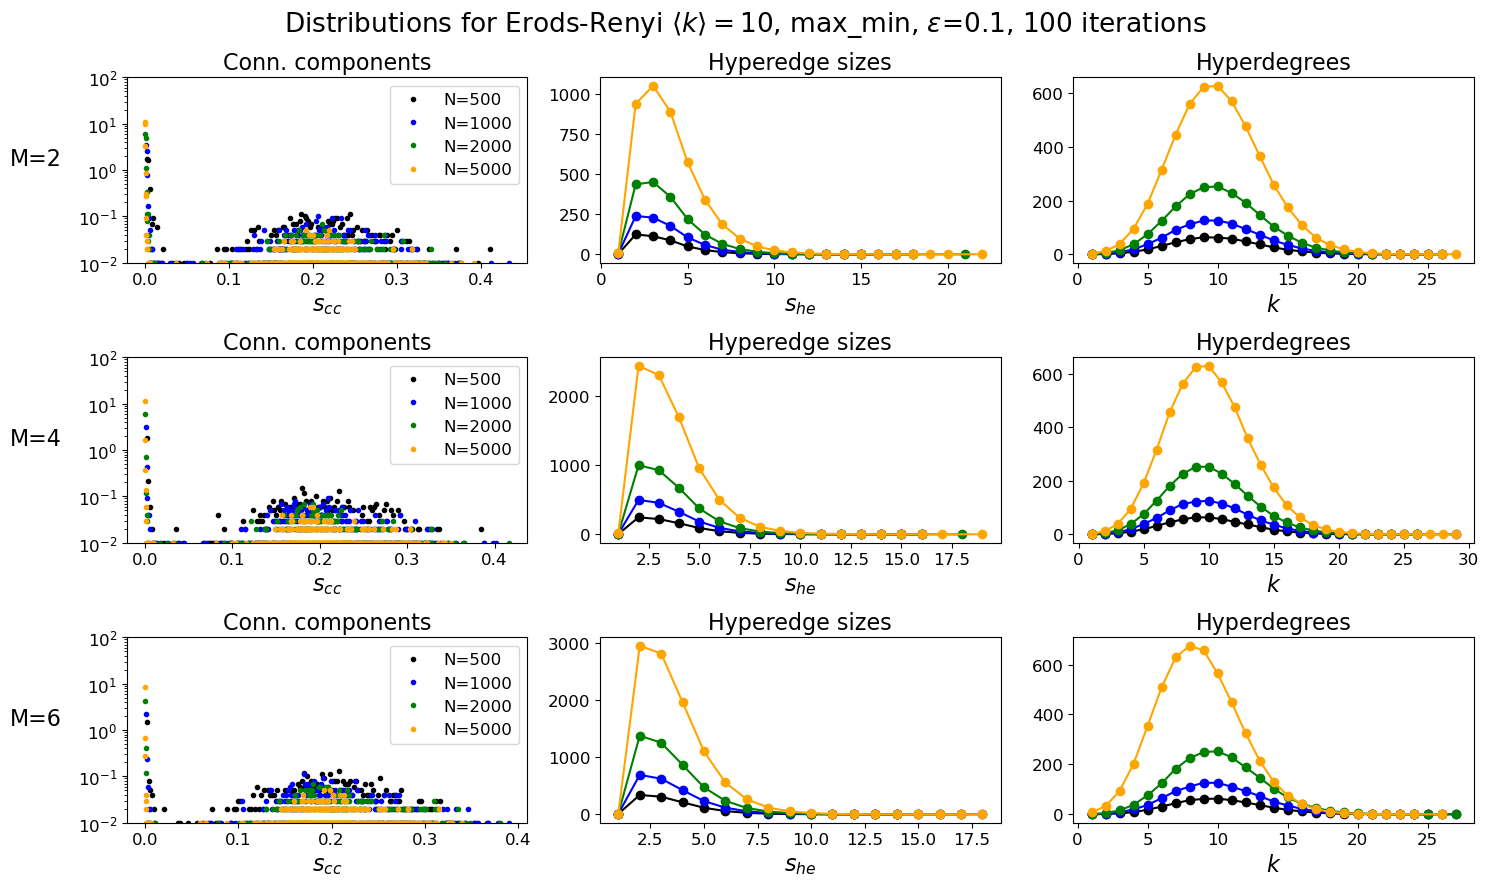

In [31]:
cond = 'max_min'
epsilon = 0.1
Ns = [500, 1000, 2000, 5000]
Ms = [2, 4, 6]

ncol = 3
fig, axs = plt.subplots(len(Ms), ncol, figsize=(15, 3*len(Ms)))
ttl_size = 16
lgd_size = 12
colors = ['black', 'blue', 'green', 'orange']  # one color for each value of N

for M in Ms:

    with open(f'../results/ER_M{M}_{cond}_distributions_eps_{epsilon}.pkl', 'rb') as f:
        results = pickle.load(f)

    sizes_cc = results['sizes_cc']
    sizes_he = results['sizes_he']
    sizes_hd = results['sizes_hd']
    n_iter = results['n_iterations']
    k_avg = results['k_avg']

    i = Ms.index(M)
    for N,clr in zip(Ns, colors):
        
        x0 = [j/N for j in sorted(sizes_cc[N].keys())]
        y0 = [sizes_cc[N][j] for j in sorted(sizes_cc[N].keys())]
        axs[i,0].plot(x0, y0, color=clr, marker='o', markersize=3, linewidth=0, label=f'N={N}')
        axs[i,0].set_yscale('log')
        axs[i,0].set_ylim([1/n_iter, n_iter])
        axs[i,0].set_xlabel(r'$s_{cc}$', fontsize=ttl_size)
        axs[i,0].set_title('Conn. components', rotation=0, fontsize=ttl_size)
        axs[i,0].legend(fontsize=lgd_size)

        x1 = sorted(sizes_he[N].keys())
        y1 = [sizes_he[N][x] for x in x1]
        axs[i,1].plot(x1, y1, color=clr, marker='o', label=f'N={N}')
        axs[i,1].set_xlabel(r'$s_{he}$', fontsize=ttl_size)
        axs[i,1].set_title('Hyperedge sizes', rotation=0, fontsize=ttl_size)

        x2 = sorted(sizes_hd[N].keys())
        y2 = [sizes_hd[N][x] for x in x2]
        axs[i,2].plot(x2, y2, color=clr, marker='o', label=f'N={N}')
        axs[i,2].set_xlabel(r'$k$', fontsize=ttl_size)
        axs[i,2].set_title('Hyperdegrees', rotation=0, fontsize=ttl_size)

        # set tick fontsize in all subplots
        for j in range(3):
            axs[i,j].tick_params(labelsize=12)
            
    axs[i,0].set_ylabel(f'M={M}', rotation=0, fontsize=ttl_size, labelpad=30)

plt.suptitle(rf'Distributions for Erods-Renyi $\langle k \rangle ={k_avg}$, {cond}, $\epsilon$={epsilon}, {n_iter} iterations',
             fontsize=int(ttl_size*1.2))

plt.tight_layout()
plt.savefig(f'../figures/ER_{cond}_distributions_eps_{epsilon}.jpg')
plt.show()